In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv(r'Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


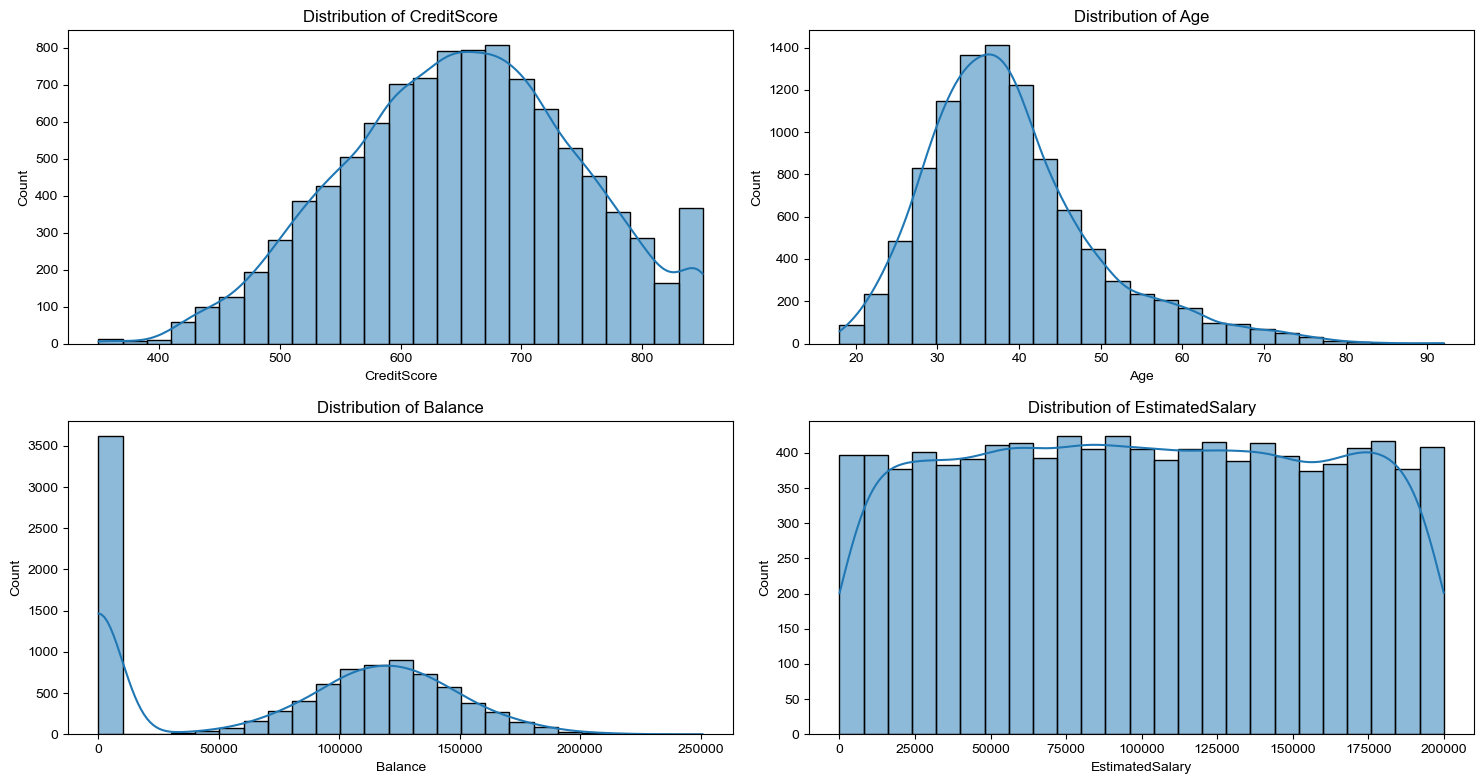

In [8]:
columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
fig, axes = plt.subplots(2, 2, figsize = (15, 8))
axes = axes.flatten()
sns.set_theme(style = 'whitegrid')

for i, col in enumerate(columns):
    sns.histplot(df[col],kde = True, ax = axes[i], bins = 25, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

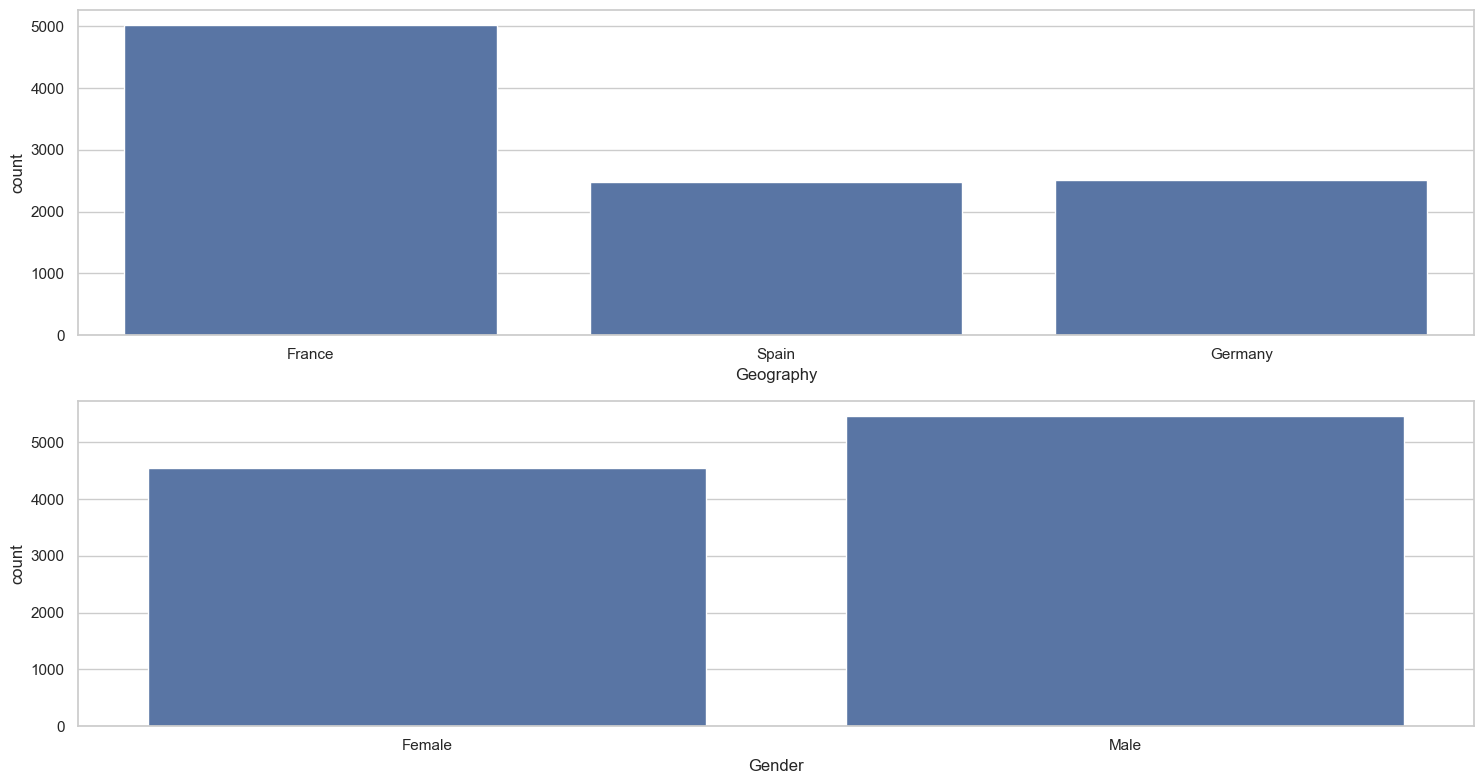

In [9]:
columns = ['Geography', "Gender"]
fig, axes = plt.subplots(2, 1, figsize = (15, 8))
axes = axes.flatten()
sns.set_theme(style = 'whitegrid')

for i, col in enumerate(columns):
    sns.countplot(x = df[col], ax = axes[i])

plt.tight_layout()
plt.show()

In [10]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

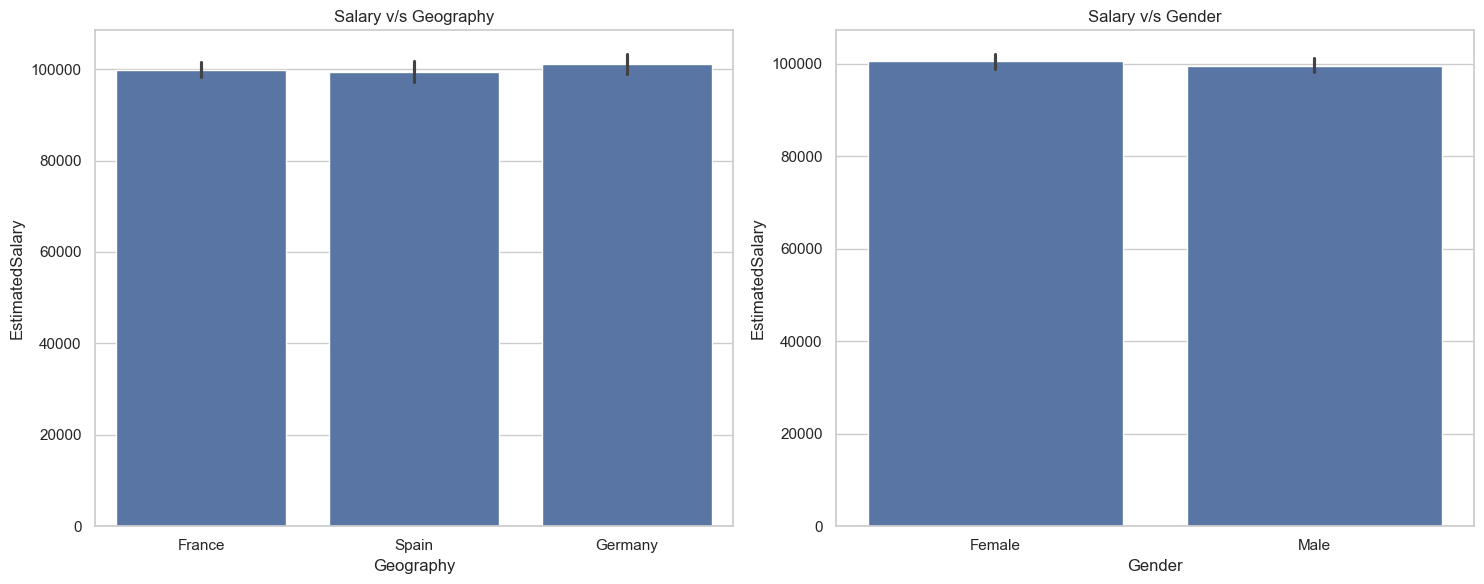

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (15, 6))
axes = axes.flatten()
sns.set_theme(style = 'whitegrid')

for i, col in enumerate(columns):
    sns.barplot(x = df[col], y = df['EstimatedSalary'], ax = axes[i])
    axes[i].set_title(f'Salary v/s {col}')

plt.tight_layout()
plt.show()

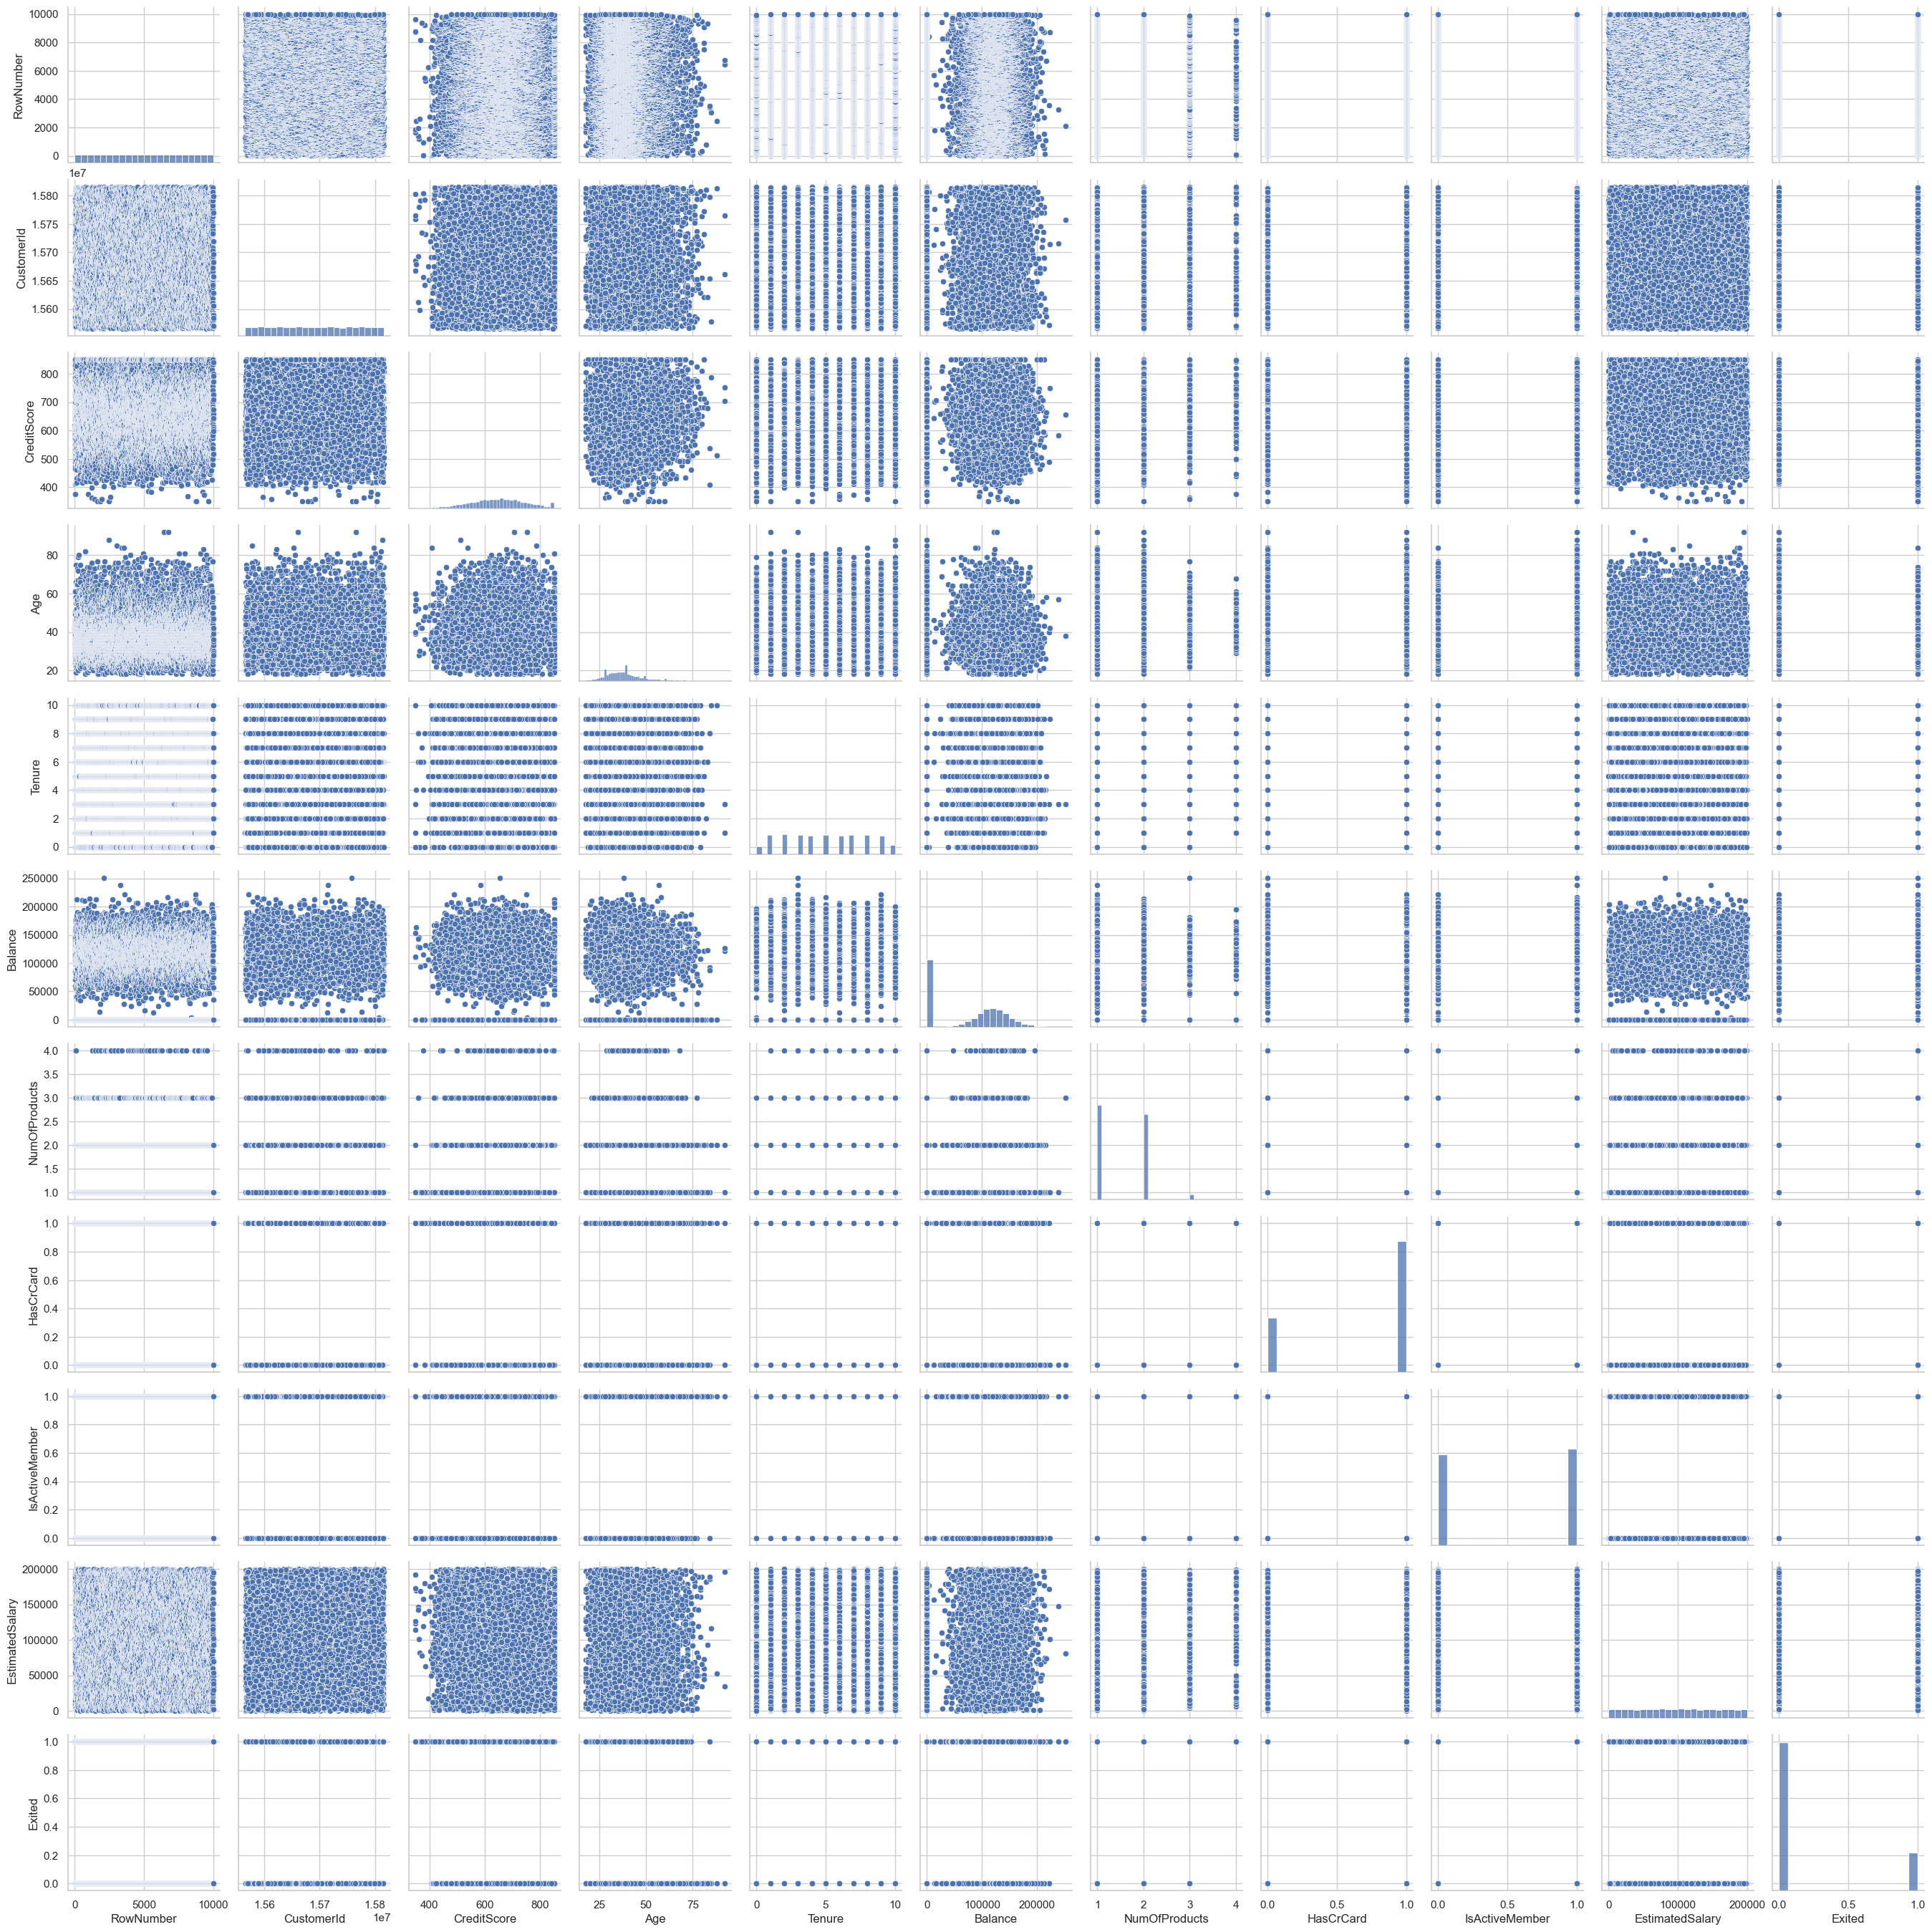

In [12]:
sns.pairplot(df)

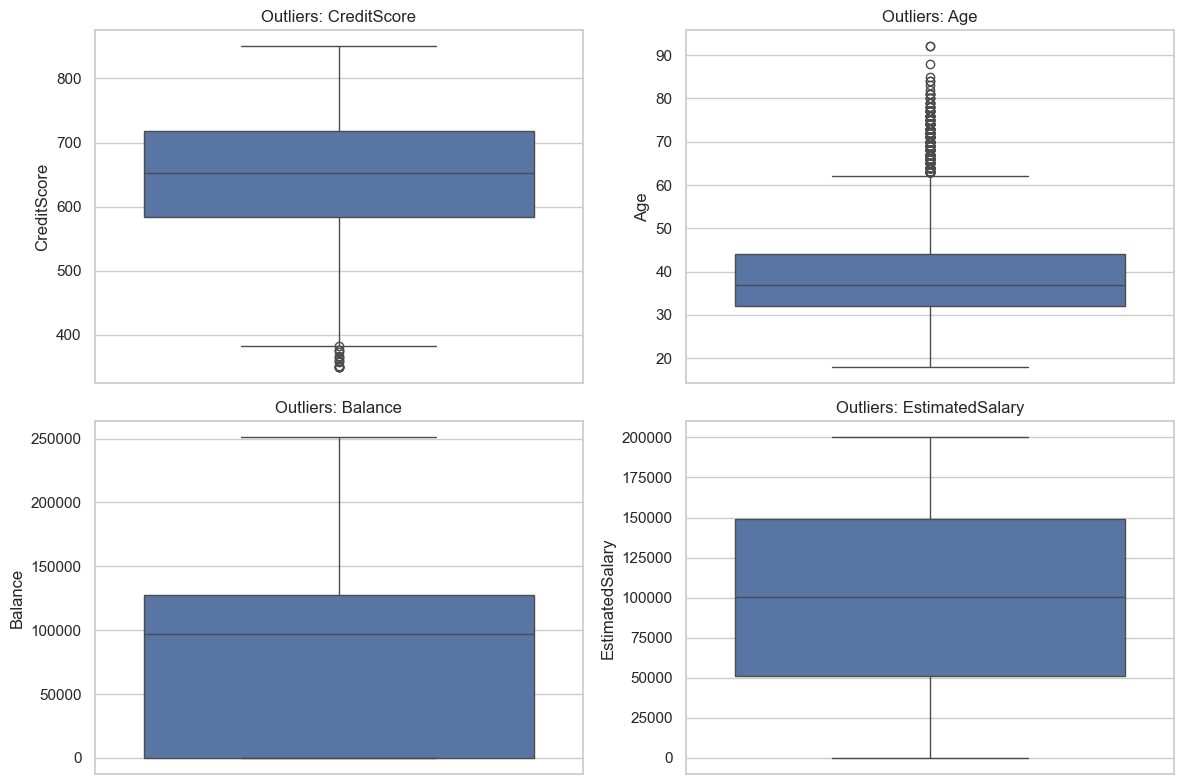

In [13]:
columns = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()
sns.set_theme(style = 'whitegrid')

for i, col in enumerate(columns):
    sns.boxplot(df[col], ax = axes[i])
    axes[i].set_title(f'Outliers: {col}')

plt.tight_layout()
plt.show()

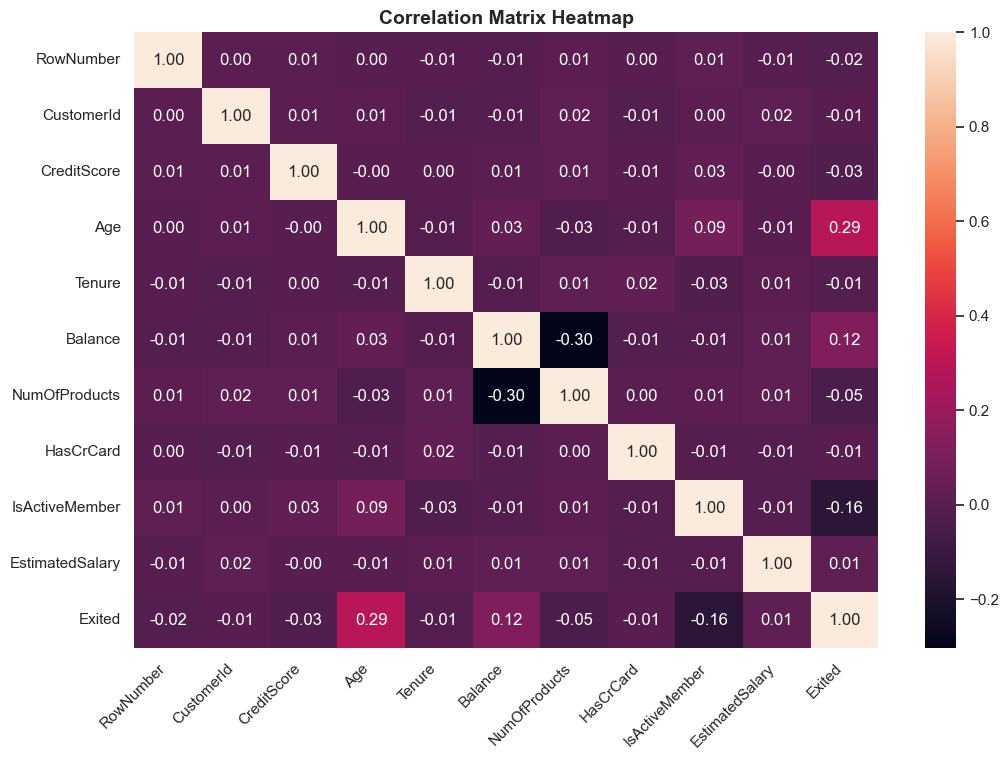

In [14]:
plt.figure(figsize = (12, 8))

sns.heatmap(
    df.corr(numeric_only = True),                  
    annot=True,                    
    fmt=".2f",                             
)

plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') 
plt.show()


## Data Cleaning

In [15]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1, inplace = True)

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Outliers Hanling

In [17]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df['Age'] = df['Age'].clip(upper = upper_bound)

<Axes: ylabel='Age'>

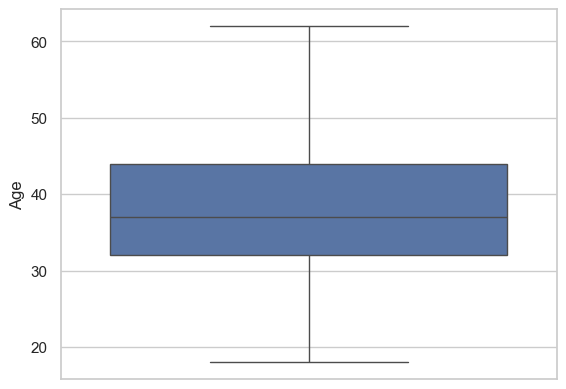

In [18]:
sns.boxplot(df['Age'])

In [19]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

## Data Preprocessing

In [20]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [21]:
df['Gender'] = df['Gender'].map({
    'Female' : 1,
    'Male' : 0
})

In [22]:
df.rename(columns={'Gender': 'is_Female'}, inplace=True)

In [23]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [24]:
df = pd.get_dummies(df, drop_first = True, dtype = int)

In [25]:
df.head(3)

,CreditScore,is_Female,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0


## Features Engineering

In [26]:
df['BalanceToSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

In [27]:
df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)

In [28]:
df['HighRiskActive'] = ((df['IsActiveMember'] == 1) & (df['Balance'] == 0)).astype(int)

In [29]:
df.head(3)

,CreditScore,is_Female,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,BalanceToSalaryRatio,ProductsPerYear,HighRiskActive
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.000000,0.333333,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,0.744670,0.500000,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,1.401362,0.333333,0


## Features Selecton

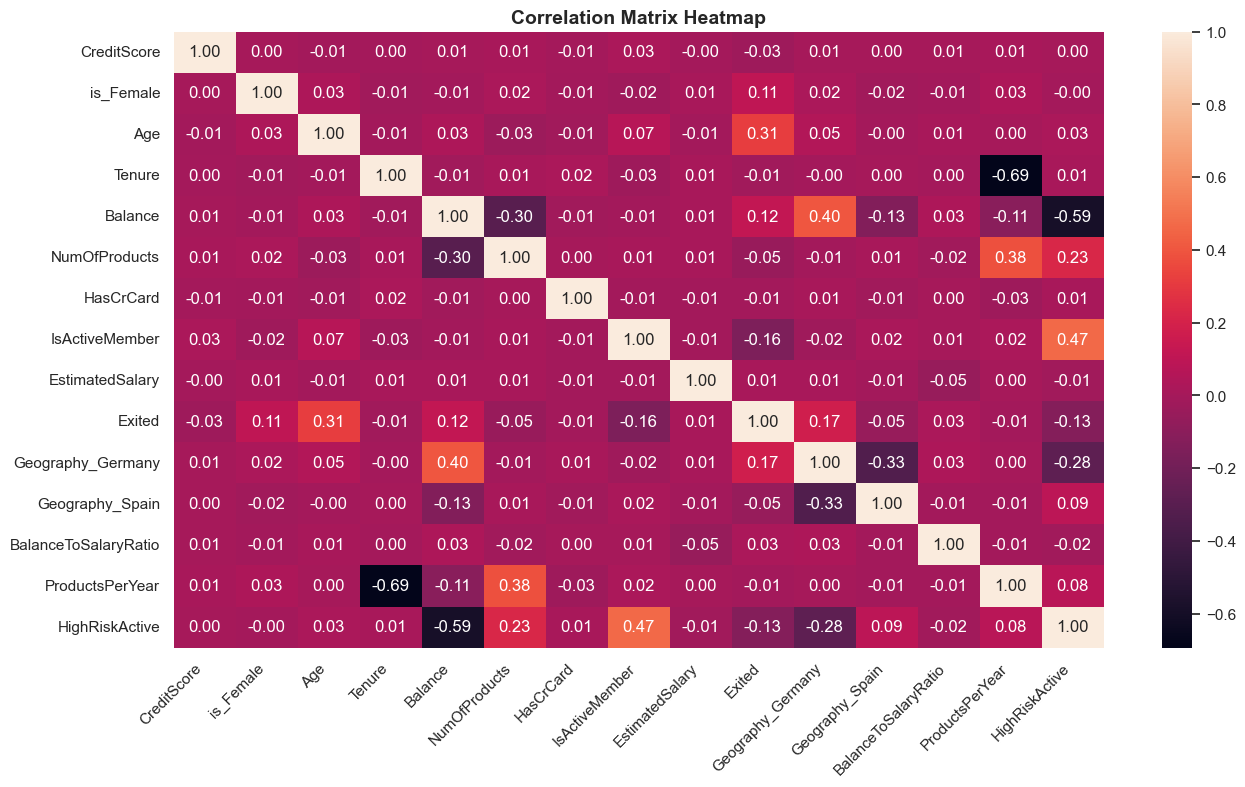

In [30]:
plt.figure(figsize = (15, 8))

sns.heatmap(
    df.corr(numeric_only = True),                  
    annot=True,                    
    fmt=".2f",                             
)

plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') 
plt.show()

In [37]:
final_features = [
    'Age', 'NumOfProducts', 'IsActiveMember', 'ProductsPerYear', 
    'EstimatedSalary', 'CreditScore', 'Balance', 'BalanceToSalaryRatio', 
    'Geography_Germany', 'Geography_Spain', 'is_Female', 'HasCrCard', 'Exited'
]

df_cleaned = df[final_features]

In [38]:
df_cleaned.head(3)

,Age,NumOfProducts,IsActiveMember,ProductsPerYear,EstimatedSalary,CreditScore,Balance,BalanceToSalaryRatio,Geography_Germany,Geography_Spain,is_Female,HasCrCard,Exited
0,42,1,1,0.333333,101348.88,619,0.00,0.000000,0,0,1,1,1
1,41,1,1,0.500000,112542.58,608,83807.86,0.744670,0,1,1,0,0
2,42,3,0,0.333333,113931.57,502,159660.80,1.401362,0,0,1,1,1


## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop(columns=['Exited'])
y = df_cleaned['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size (X_train): {X_train.shape}")
print(f"Testing set size (X_test): {X_test.shape}")


Training set size (X_train): (8000, 12)
Testing set size (X_test): (2000, 12)


In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

y_train_resampled.value_counts()

Exited
1    6370
0    6370
Name: count, dtype: int64

## Standard Scaling

In [42]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaling Done")

Scaling Done


## Model Training

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train_scaled, y_train_resampled)

y_pred = model.predict(X_test_scaled)

print("--- Model Performance Report ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Model Performance Report ---
Accuracy Score: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.56      0.60      0.58       407

    accuracy                           0.82      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.83      0.82      0.83      2000



## Feature Importance

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

importances = model.feature_importances_
feature_names = X.columns  

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\n--- Top Features Influencing Churn ---")
feature_imp_df


--- Top Features Influencing Churn ---


,Feature,Importance
0,Age,0.212625
3,ProductsPerYear,0.112971
1,NumOfProducts,0.110993
2,IsActiveMember,0.109068
4,EstimatedSalary,0.103787
5,CreditScore,0.095596
6,Balance,0.094803
7,BalanceToSalaryRatio,0.082176
9,Geography_Spain,0.029983
11,HasCrCard,0.020543
